# 실습문제 7 프로젝트 과제 ----------------------------------------------------------------
현재 Grocery 데이터 대신 다른 데이터를 사용하여 연관분석을 수행하시오.

### 후보 데이터 --- 아래 4 개 중 하나 받아와서 씀
* Online Retail Dataset (UCI)
* Instacart Market Basket Dataset
* Kaggle Grocery Dataset
* E-Commerce Transaction Dataset

## 수행 내용
1. 데이터 수집
2. 거래 데이터 전처리
3. One-Hot Encoding
4. Support 계산
5. Confidence 계산
6. Lift 계산
7. 규칙 생성
8. 추천 상품 도출
9. 시각화
10. 결과 보고서 작성

## 최종 프로젝트 보고서 문항
1. 사용한 데이터셋 설명
2. 전체 거래 수
3. 전체 상품 수
4. 가장 많이 판매된 상품
5. 생성된 규칙 수
6. 최고 Support 규칙
7. 최고 Confidence 규칙
8. 최고 Lift 규칙
9. 추천 시스템 결과
10. 비즈니스 활용 방안


## 최종 프로젝트 보고서 문항



1. 사용한 데이터셋 설명
2. 전체 거래 수
3. 전체 상품 수
4. 가장 많이 판매된 상품
5. 생성된 규칙 수
6. 최고 Support 규칙
7. 최고 Confidence 규칙
8. 최고 Lift 규칙
9. 추천 시스템 결과
10. 비즈니스 활용 방안

## 1. 데이터 수집


In [20]:
# pip install
!pip install python-calamine
!pip install mlxtend

# import
import os, urllib.request, pandas as pd
import random
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt

# from google.colab import files

# seed
SEED = 12345
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

# device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('사용 장치:', device)


사용 장치: cpu


In [11]:
import os, urllib.request, zipfile, pandas as pd

URL = "https://archive.ics.uci.edu/static/public/352/online+retail.zip"
ZIP_PATH = "data/online_retail.zip"

os.makedirs("data", exist_ok=True)
if not os.path.exists(ZIP_PATH):
    urllib.request.urlretrieve(URL, ZIP_PATH)
    print("다운로드 완료:", ZIP_PATH)

# with zipfile.ZipFile(ZIP_PATH) as z:
#     print("zip 내부 파일:", z.namelist())
#     xlsx_name = [n for n in z.namelist() if n.lower().endswith(".xlsx")][0]
#     with z.open(xlsx_name) as f:
#         df = pd.read_excel(f, engine="openpyxl")


## 2. 거래 데이터 전처리

### 코드 1 - openpyxl 사용

- 로드속도 1분

- 데이터를 단순 for 문으로 작업해서 느림. 메모리 많이 먹음

- df.groupby().apply(...) 이 많이 느림


In [16]:
# import os, zipfile, pandas as pd

# ZIP_PATH = "data/online_retail.zip"

# # 1) zip 안의 xlsx 를 다시 읽어 df 를 깨끗한 DataFrame 으로 복구합니다.
# with zipfile.ZipFile(ZIP_PATH) as z:
#     xlsx_name = [n for n in z.namelist() if n.lower().endswith(".xlsx")][0]
#     with z.open(xlsx_name) as f:
#         df = pd.read_excel(f, engine="openpyxl")

# print(df.shape)
# df.head()

# # 결측치 확인
# print(df.isnull().sum())
# missing_ratio = (df.isnull().sum() / len(df)) * 100
# print(missing_ratio.sort_values(ascending=False))

# df.info()
# print("-----------------------------------------")

# # 2) DataFrame 인지, 컬럼이 뭔지 확인합니다.
# print("타입:", type(df).__name__)
# print("컬럼:", list(df.columns))
# print("-----------------------------------------")

# # 3) 버전별 컬럼 이름 표준화
# df = df.rename(columns={"Invoice": "InvoiceNo", "Customer ID": "CustomerID"})
# print("-----------------------------------------")

# # 4) 결측/취소/음수수량 정리
# df = df.dropna(subset=["Description", "CustomerID"]).copy()
# df["Description"] = df["Description"].astype(str).str.strip()
# df = df[df["Quantity"] > 0]
# df = df[~df["InvoiceNo"].astype(str).str.startswith("C")]
# print("-----------------------------------------")

# # 5) 거래(InvoiceNo)별 상품 리스트로 변환
# transactions = df.groupby("InvoiceNo")["Description"].apply(lambda s: list(set(s))).tolist()

# num_transactions = len(transactions)
# all_items = sorted(set(item for t in transactions for item in t))
# num_items = len(all_items)

# print("-----------------------------------------")
# print("전체 거래 수:", num_transactions)
# print("전체 고유 아이템 수:", num_items)
# print("처음 5개 거래:")
# for i, t in enumerate(transactions[:5], start=1):
#     print(f"거래 {i}:", t)
# print("-----------------------------------------")


(541909, 8)
InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64
CustomerID     24.926694
Description     0.268311
StockCode       0.000000
InvoiceNo       0.000000
Quantity        0.000000
InvoiceDate     0.000000
UnitPrice       0.000000
Country         0.000000
dtype: float64
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    541909 non-null  object        
 1   StockCode    541909 non-null  object        
 2   Description  540455 non-null  object        
 3   Quantity     541909 non-null  int64         
 4   InvoiceDate  541909 non-null  datetime64[ns]
 5   UnitPrice    541909 non-null  float64       
 6   CustomerID   406829 non-null  float64       
 7   Country      541909

### 코드 2 - 판다스 백터 & calamine 사용

- 로드 속도 15 sec

In [19]:
import os, zipfile, pandas as pd

ZIP_PATH = "data/online_retail.zip"

# 1. calamine 엔진으로 초고속 로드
with zipfile.ZipFile(ZIP_PATH) as z:
    xlsx_name = [n for n in z.namelist() if n.lower().endswith(".xlsx")][0]
    with z.open(xlsx_name) as f:
        df = pd.read_excel(f, engine="calamine")

print("1단계 완료: 깨끗한 원본 데이터 초고속 로드 성공 (행/열):", df.shape)

# 2. 기초 전처리
df = df.rename(columns={"Invoice": "InvoiceNo", "Customer ID": "CustomerID"})
df = df.dropna(subset=["Description", "CustomerID"]).copy()
df["Description"] = df["Description"].astype(str).str.strip()

# *** [교정 완료] 맨 끝 괄호 구문을 ).astype(str).str.startswith("C"))] 로 올바르게 닫았습니다.
df = df[(df["Quantity"] > 0) & (~df["InvoiceNo"].astype(str).str.startswith("C"))]

# 3. 고속 알고리즘 적용하여 리스트 변환
df_unique = df[["InvoiceNo", "Description"]].drop_duplicates()
transactions = df_unique.groupby("InvoiceNo")["Description"].agg(list).tolist()

# 4. 최종 결과 출력
num_transactions = len(transactions)
all_items = sorted(set(item for t in transactions for item in t))
num_items = len(all_items)

print("-----------------------------------------")
print("전체 거래 수:", num_transactions)
print("전체 고유 아이템 수:", num_items)
print("처음 5개 거래:")
for i, t in enumerate(transactions[:5], start=1):
    print(f"거래 {i}:", t)
print("-----------------------------------------")

🔄 1단계 완료: 깨끗한 원본 데이터 초고속 로드 성공 (행/열): (541909, 8)
-----------------------------------------
전체 거래 수: 18536
전체 고유 아이템 수: 3866
처음 5개 거래:
거래 1: ['WHITE HANGING HEART T-LIGHT HOLDER', 'WHITE METAL LANTERN', 'CREAM CUPID HEARTS COAT HANGER', 'KNITTED UNION FLAG HOT WATER BOTTLE', 'RED WOOLLY HOTTIE WHITE HEART.', 'SET 7 BABUSHKA NESTING BOXES', 'GLASS STAR FROSTED T-LIGHT HOLDER']
거래 2: ['HAND WARMER UNION JACK', 'HAND WARMER RED POLKA DOT']
거래 3: ['ASSORTED COLOUR BIRD ORNAMENT', "POPPY'S PLAYHOUSE BEDROOM", "POPPY'S PLAYHOUSE KITCHEN", 'FELTCRAFT PRINCESS CHARLOTTE DOLL', 'IVORY KNITTED MUG COSY', 'BOX OF 6 ASSORTED COLOUR TEASPOONS', 'BOX OF VINTAGE JIGSAW BLOCKS', 'BOX OF VINTAGE ALPHABET BLOCKS', 'HOME BUILDING BLOCK WORD', 'LOVE BUILDING BLOCK WORD', 'RECIPE BOX WITH METAL HEART', 'DOORMAT NEW ENGLAND']
거래 4: ['JAM MAKING SET WITH JARS', 'RED COAT RACK PARIS FASHION', 'YELLOW COAT RACK PARIS FASHION', 'BLUE COAT RACK PARIS FASHION']
거래 5: ['BATH BUILDING BLOCK WORD']
-----------------

## 3. One-Hot Encoding


### 코드 1 - 직접 구현

 - 3 sec

In [13]:
item_to_idx = {item: idx for idx, item in enumerate(all_items)}

idx_to_item = {idx: item for item, idx in item_to_idx.items()}

X = torch.zeros((num_transactions, num_items), dtype=torch.float32)

for row_idx, transaction in enumerate(transactions):
    for item in transaction:
        col_idx = item_to_idx[item]

        X[row_idx, col_idx] = 1.0

print("one-hot 행렬 크기:", X.shape)

print("처음 5개 거래 x 처음 10개 아이템 행렬:")
print(X[:5, :10])

print("처음 10개 아이템 이름:")
print(all_items[:10])


one-hot 행렬 크기: torch.Size([18536, 3866])
처음 5개 거래 x 처음 10개 아이템 행렬:
tensor([[0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0., 0., 0., 0.]])
처음 10개 아이템 이름:
['10 COLOUR SPACEBOY PEN', '12 COLOURED PARTY BALLOONS', '12 DAISY PEGS IN WOOD BOX', '12 EGG HOUSE PAINTED WOOD', '12 HANGING EGGS HAND PAINTED', '12 IVORY ROSE PEG PLACE SETTINGS', '12 MESSAGE CARDS WITH ENVELOPES', '12 PENCIL SMALL TUBE WOODLAND', '12 PENCILS SMALL TUBE RED RETROSPOT', '12 PENCILS SMALL TUBE SKULL']


### 코드 2 - mlxtend 사용

 - 1 sec

In [21]:
import pandas as pd
from mlxtend.preprocessing import TransactionEncoder

# 1. mlxtend의 전용 인코더 가져오기
te = TransactionEncoder()

# 2. [핵심] 자동으로 아이템을 파악하고 원핫 인코딩된 불린(Boolean) 행렬 생성
# float32 대신 True/False(1비트)를 사용하므로 메모리 사용량이 1/32로 줄어듭니다.
te_ary = te.fit(transactions).transform(transactions)

# 3. 판다스 데이터프레임으로 압축 변환
X_df = pd.DataFrame(te_ary, columns=te.columns_)

print("원핫 행렬 크기:", X_df.shape)
# 앞쪽 5개 행과 10개 열 확인
print(X_df.iloc[:5, :10])

원핫 행렬 크기: (18536, 3866)
   10 COLOUR SPACEBOY PEN  12 COLOURED PARTY BALLOONS  \
0                   False                       False   
1                   False                       False   
2                   False                       False   
3                   False                       False   
4                   False                       False   

   12 DAISY PEGS IN WOOD BOX  12 EGG HOUSE PAINTED WOOD  \
0                      False                      False   
1                      False                      False   
2                      False                      False   
3                      False                      False   
4                      False                      False   

   12 HANGING EGGS HAND PAINTED  12 IVORY ROSE PEG PLACE SETTINGS  \
0                         False                             False   
1                         False                             False   
2                         False                             False   
3 

## 4. Support 계산

In [23]:
# ============================================================
# 5. 아이템 빈도와 지지도 계산
# ============================================================

# 지지도(support)는 전체 거래 중 특정 아이템이 등장한 거래의 비율입니다.
# 예: 전체 100건 중 우유가 25건이면 우유의 support는 25 / 100 = 0.25입니다.

# X.mean(dim=0)은 각 열의 평균을 계산합니다.
# one-hot 값이 0 또는 1이므로 평균은 곧 각 아이템의 거래 비율, 즉 지지도입니다.
item_support_tensor = X.mean(dim=0)

# torch 텐서를 pandas DataFrame으로 변환하기 위해 numpy 배열로 바꿉니다.
item_support = item_support_tensor.numpy()

# 아이템별 지지도 표를 만듭니다.
item_freq_df = pd.DataFrame({
    "item": all_items,
    "support": item_support,
    "count": (item_support_tensor * num_transactions).to(torch.int64).numpy()
})

# 지지도 기준으로 내림차순 정렬합니다.
item_freq_df = item_freq_df.sort_values("support", ascending=False).reset_index(drop=True)

# 상위 10개 아이템을 출력합니다.
item_freq_df.head(20)


,item,support,count
0,WHITE HANGING HEART T-LIGHT HOLDER,0.106334,1971
1,REGENCY CAKESTAND 3 TIER,0.091929,1704
2,JUMBO BAG RED RETROSPOT,0.086319,1600
3,PARTY BUNTING,0.074450,1380
4,ASSORTED COLOUR BIRD ORNAMENT,0.074180,1375
5,LUNCH BAG RED RETROSPOT,0.069486,1288
6,SET OF 3 CAKE TINS PANTRY DESIGN,0.061826,1146
7,POSTAGE,0.059290,1099
8,LUNCH BAG BLACK SKULL.,0.056754,1052
9,PACK OF 72 RETROSPOT CAKE CASES,0.055514,1029


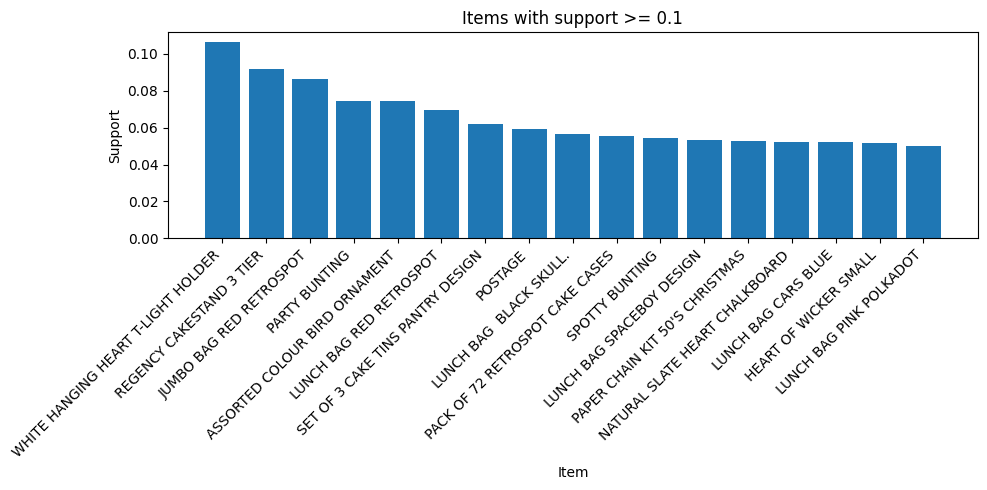

In [27]:
# 지지도 0.1 이상 아이템 시각화

support_01_df = item_freq_df[item_freq_df["support"] >= 0.05]

plt.figure(figsize=(10, 5))
plt.bar(support_01_df["item"], support_01_df["support"])
plt.xticks(rotation=45, ha="right")

plt.title("Items with support >= 0.1")
plt.xlabel("Item")
plt.ylabel("Support")

plt.tight_layout()

plt.show()


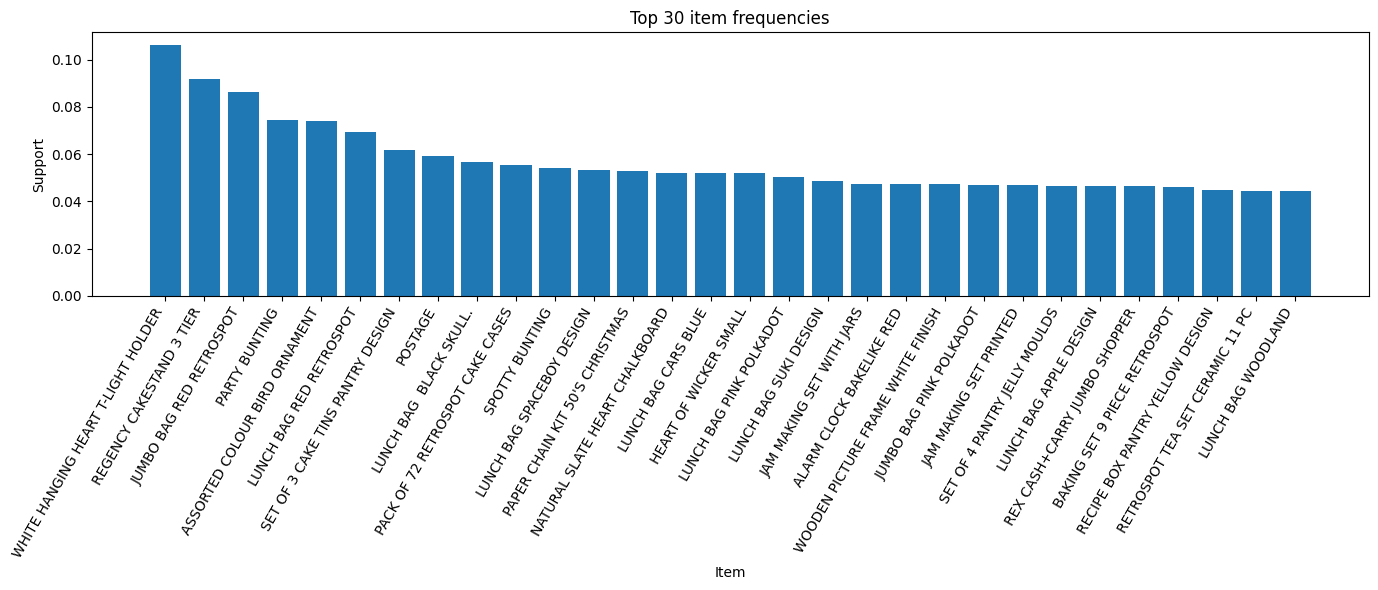

In [28]:
# 지지도 상위 30개 아이템만 선택합니다.
top30_df = item_freq_df.head(30)

plt.figure(figsize=(14, 6))
plt.bar(top30_df["item"], top30_df["support"])
plt.xticks(rotation=60, ha="right")

plt.title("Top 30 item frequencies")
plt.xlabel("Item")
plt.ylabel("Support")
plt.tight_layout()

plt.show()


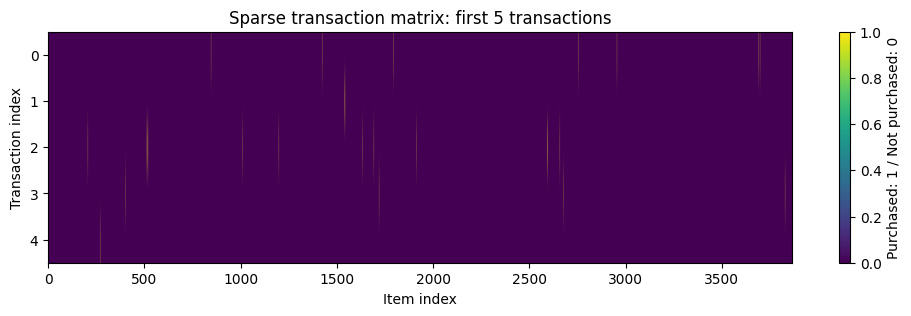

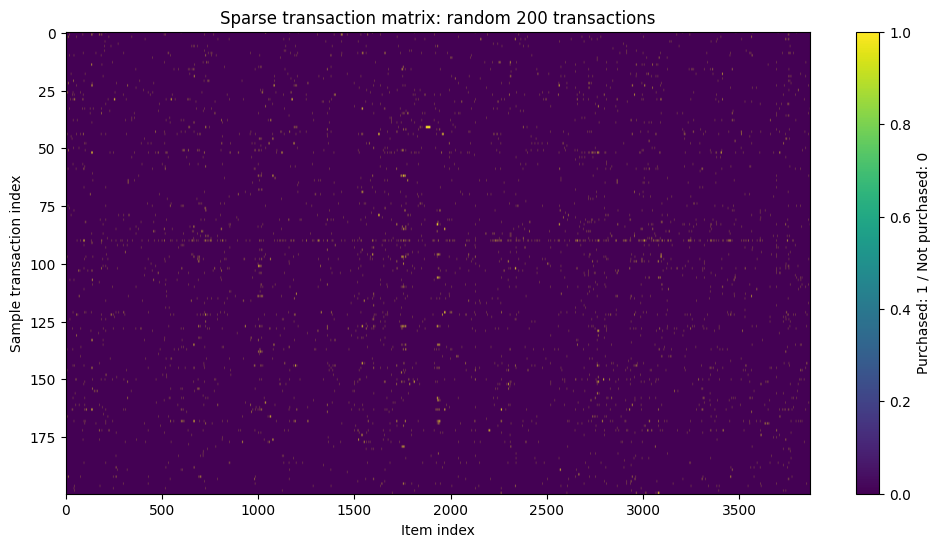

In [29]:
# 거래-아이템 희소 행렬 시각화

plt.figure(figsize=(12, 3))
plt.imshow(X[:5].numpy(), aspect="auto")

plt.title("Sparse transaction matrix: first 5 transactions")
plt.xlabel("Item index")
plt.ylabel("Transaction index")

plt.colorbar(label="Purchased: 1 / Not purchased: 0")

plt.show()

torch.manual_seed(42)

sample_indices = torch.randperm(num_transactions)[:200]

plt.figure(figsize=(12, 6))
plt.imshow(X[sample_indices].numpy(), aspect="auto")

plt.title("Sparse transaction matrix: random 200 transactions")
plt.xlabel("Item index")
plt.ylabel("Sample transaction index")

plt.colorbar(label="Purchased: 1 / Not purchased: 0")

plt.show()


In [31]:
# itemset 지지도 계산 함수 정의

def calculate_itemset_support(X, item_indices):
    item_indices = list(item_indices)

    selected = X[:, item_indices]

    both_purchased = selected.prod(dim=1)

    support = both_purchased.mean().item()

    return support

test_items = item_freq_df.head(2)["item"].tolist()
test_indices = [item_to_idx[item] for item in test_items]
test_support = calculate_itemset_support(X, test_indices)

print("테스트 아이템:", test_items)
print("동시 등장 지지도:", test_support)


테스트 아이템: ['WHITE HANGING HEART T-LIGHT HOLDER', 'REGENCY CAKESTAND 3 TIER']
동시 등장 지지도: 0.01267803180962801


## 5. Confidence 계산


### 코드 :

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

NameError: name 'frequent_itemsets' is not defined

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

In [32]:
from itertools import combinations
import pandas as pd

# 결과를 저장할 리스트
summary_results = []

for value in confidence_values:
    MIN_SUPPORT = 0.007
    MIN_CONFIDENCE = value
    MIN_LEN = 2
    MAX_LEN = 4

    # 1. 단일 아이템 필터링
    frequent_single_items = [
        item_to_idx[row.item]
        for row in item_freq_df.itertuples(index=False)
        if row.support >= MIN_SUPPORT
    ]

    num_single = len(frequent_single_items)
    print(f"\n[실행 중] value : {value:.4f} -> 단일 아이템 수: {num_single}")

    frequent_itemsets = {}
    current_frequent = {}

    for item_idx in frequent_single_items:
        itemset = (item_idx,)
        support = item_support_tensor[item_idx].item()
        frequent_itemsets[itemset] = support
        current_frequent[itemset] = support

    # 길이별 개수를 기록할 딕셔너리 (표 생성용)
    len_counts = {2: 0, 3: 0, 4: 0}

    # 2. k개 조합 생성 (가지치기 적용)
    for k in range(2, MAX_LEN + 1):
        count_k = 0
        next_frequent = {}

        prev_items = sorted(list(set(item for t in current_frequent.keys() for item in t)))

        for candidate in combinations(prev_items, k):
            is_valid_candidate = True
            for sub_set in combinations(candidate, k - 1):
                sorted_sub_set = tuple(sorted(sub_set))
                if sorted_sub_set not in current_frequent:
                    is_valid_candidate = False
                    break

            if not is_valid_candidate:
                continue

            support = calculate_itemset_support(X, candidate)

            if support >= MIN_SUPPORT:
                sorted_itemset = tuple(sorted(candidate))
                frequent_itemsets[sorted_itemset] = support
                next_frequent[sorted_itemset] = support
                count_k += 1

        len_counts[k] = count_k
        print(f"  길이 {k} 빈발 itemset 수: {count_k}")

        current_frequent = next_frequent

        if not current_frequent:
            print(f"  -> 길이 {k}에서 빈발 itemset이 없어 조기 종료합니다.")
            break

    total_count = len(frequent_itemsets)
    print(f"  전체 빈발 itemset 수: {total_count}")

    # --------------------------------------------------------
    # [원래 코드 규칙 생성 기능 연동 및 개수 파악]
    # --------------------------------------------------------
    rules_df = generate_rules(frequent_itemsets, MIN_CONFIDENCE)
    rule_count = len(rules_df)
    print(f"  생성된 연관규칙 수: {rule_count}")
    # --------------------------------------------------------

    # [표 생성용 데이터 추가]
    summary_results.append({
        "value": f"{value:.4f}",
        "단일 아이템 수 (길이 1)": num_single,
        "길이 2 개수": len_counts[2],
        "길이 3 개수": len_counts[3],
        "길이 4 개수": len_counts[4],
        "전체 빈발 itemset 수": total_count,
        "생성 규칙 수 (count)": rule_count
    })

# ============================================================
# 3. 최종 결과를 Pandas 표(DataFrame)로 출력
# ============================================================
print("\n" + "="*80)
print("             ★ 아프리오리 요약 결과 표 (규칙 카운트 포함) ★")
print("="*80)
df_summary = pd.DataFrame(summary_results)
print(df_summary.to_string(index=False))


NameError: name 'confidence_values' is not defined

## 6. Lift 계산


## 7. 규칙 생성


## 8. 추천 상품 도출


## 9. 시각화


## 10. 결과 보고서 작성
